In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from nltools.file_reader import onsets_to_dm
from nltools.stats import regress, zscore
from nltools.data import Brain_Data, Design_Matrix
from nltools.stats import find_spikes 
from nilearn.plotting import view_img, glass_brain, plot_stat_map
from bids import BIDSLayout, BIDSValidator

In [2]:
data_dir = '../ds004636'
layout = BIDSLayout(data_dir, derivatives=True)

In [3]:
def mutate_layout(layout, subject,task):
    onsets = pd.read_csv(layout.get(subject=subject, task=task,suffix='events')[0].path, sep='\t')
    print(onsets)
# onsets = mutate_layout(layout, 's061',task='stroop')   

In [4]:
def load_bids_events(layout, subject,task):
    '''Create a design_matrix instance from BIDS event file'''
    tr = layout.get_tr()
    layout_get=layout.get(subject=subject,task=task,scope='raw', suffix='bold')[0].path
    n_tr = nib.load(layout_get).shape[-1] #width and length = 100, height=64, timeseries=339s
    onsets = pd.read_csv(layout.get(subject=subject, task=task,suffix='events')[0].path, sep='\t')
    onsets=onsets[['onset','duration','condition']]
    onsets=onsets.rename(columns={'onset':'Onset','duration':'Duration','condition':'Stim'})
    print(onsets)
    return onsets_to_dm(onsets, sampling_freq=1/tr, run_length=n_tr)

dm = load_bids_events(layout, 's061',task='stroop')

      Onset  Duration         Stim
0     3.506       1.5  incongruent
1     5.508       1.5    congruent
2     7.510       1.5  incongruent
3     9.783       1.5  incongruent
4    11.784       1.5    congruent
..      ...       ...          ...
91  199.139       1.5    congruent
92  201.141       1.5  incongruent
93  203.143       1.5    congruent
94  205.145       1.5  incongruent
95  207.147       1.5    congruent

[96 rows x 3 columns]


In [5]:
dm.info()

<class 'nltools.data.design_matrix.Design_Matrix'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   incongruent  339 non-null    float64
 1   congruent    339 non-null    float64
dtypes: float64(2)
memory usage: 5.4 KB


In [6]:
dm

,incongruent,congruent
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
334,0.0,0.0
335,0.0,0.0
336,0.0,0.0
337,0.0,0.0


<Axes: >

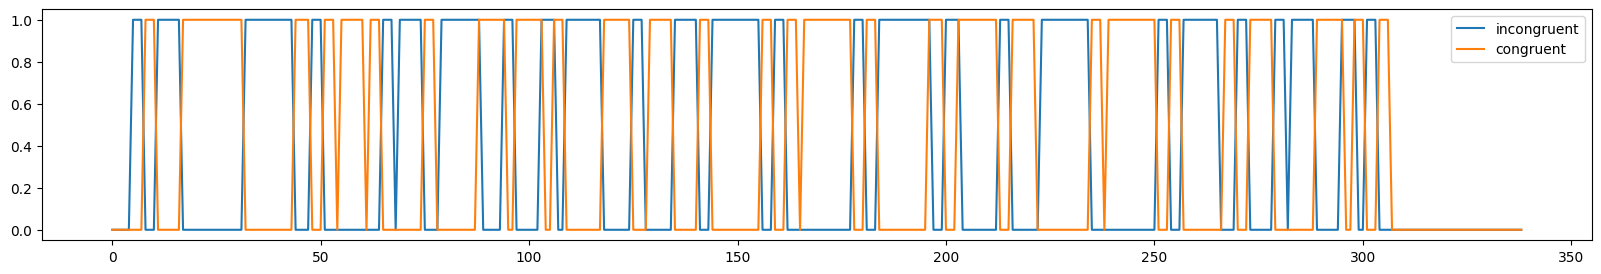

In [7]:
f,a = plt.subplots(figsize=(20,3))
dm.plot(ax=a)

<Axes: >

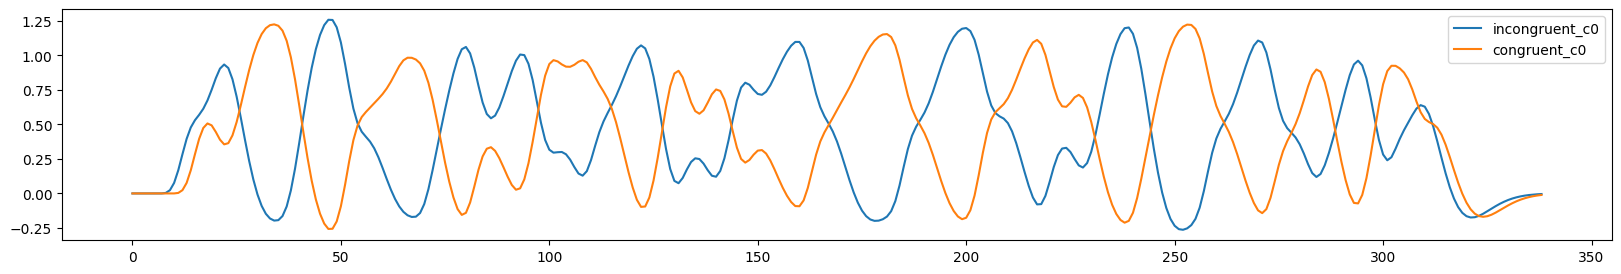

In [8]:
dm_conv=dm.convolve()
f,a = plt.subplots(figsize=(20,3))
dm_conv.plot(ax=a)

<Axes: >

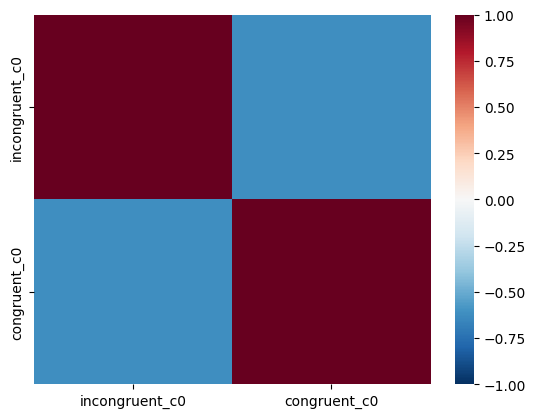

In [9]:
sns.heatmap(dm_conv.corr(), vmin=-1, vmax=1, cmap='RdBu_r')

Text(0, 0.5, 'Variance Inflation Factor')

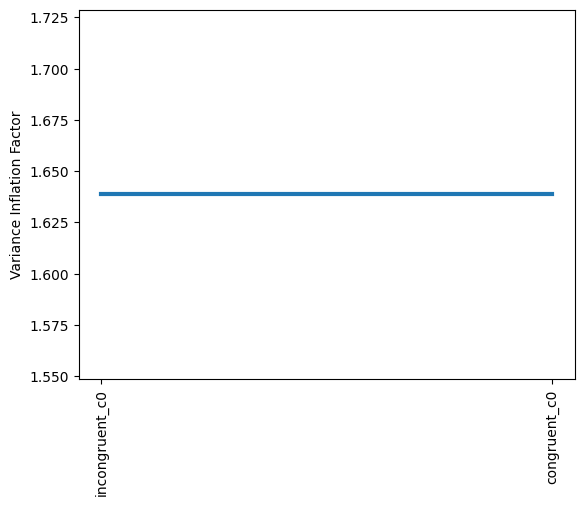

In [10]:
plt.plot(dm_conv.columns, dm_conv.vif(), linewidth=3)
plt.xticks(rotation=90)
plt.ylabel('Variance Inflation Factor')

<Axes: >

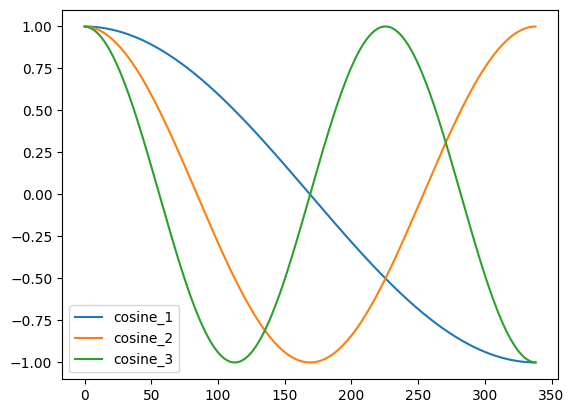

In [11]:
dm_conv_filt = dm_conv.add_dct_basis(duration=128)
dm_conv_filt.iloc[:,2:].plot()

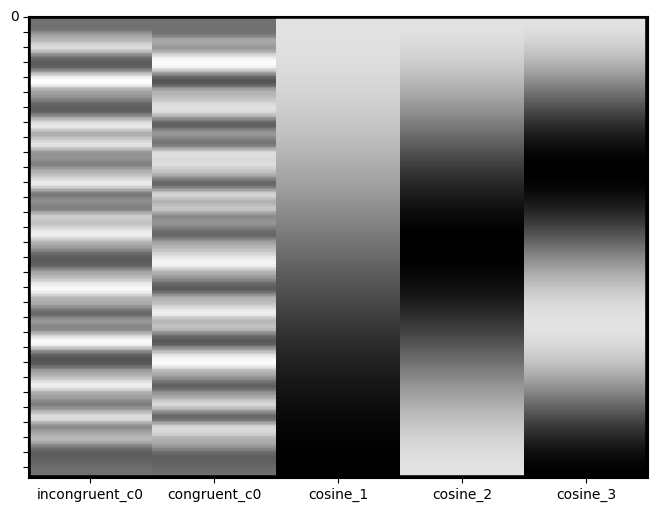

In [12]:
# account for low freq artifacts
dm_conv_filt = dm_conv.add_dct_basis(duration=128)
dm_conv_filt.heatmap()

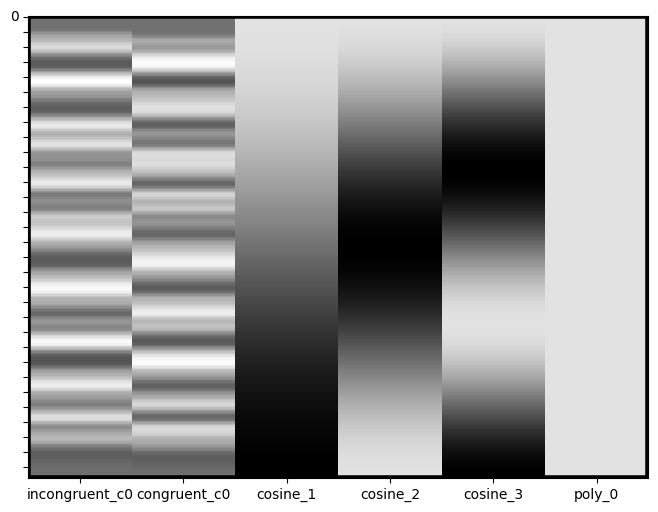

In [13]:
#  add intercept in the mode (represent base_line activity)
dm_conv_filt_poly = dm_conv_filt.add_poly()
dm_conv_filt_poly.heatmap()

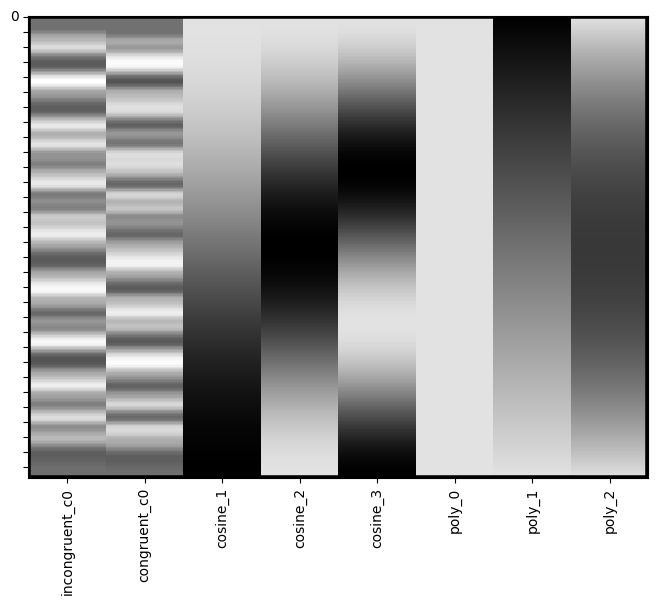

In [14]:
# account for low frequency drifts (linear trends)
dm_conv_filt_poly = dm_conv_filt.add_poly(order=2, include_lower=True)
dm_conv_filt_poly.heatmap()

In [25]:
sub = 's061'
# print(layout.get(subject=sub,task='stroop',scope='derivatives', suffix='bold'))
layout_get=layout.get(absolute_paths="/Users/ibrayyilmaz/Desktop/EnkaviLab/practice_code/ds004636/derivatives/fmriprep/sub-s061/ses-2/func/sub-s061_ses-2_task-stroop_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz")
print(layout_get)
# data = Brain_Data(layout_get)

[<BIDSFile filename='/Users/ibrayyilmaz/Desktop/EnkaviLab/practice_code/GLM/../ds004636/CHANGES'>, <BIDSJSONFile filename='/Users/ibrayyilmaz/Desktop/EnkaviLab/practice_code/GLM/../ds004636/dataset_description.json'>, <BIDSJSONFile filename='/Users/ibrayyilmaz/Desktop/EnkaviLab/practice_code/GLM/../ds004636/derivatives/mriqc/dataset_description.json'>, <BIDSJSONFile filename='/Users/ibrayyilmaz/Desktop/EnkaviLab/practice_code/GLM/../ds004636/derivatives/mriqc/sub-s061/ses-1/anat/sub-s061_ses-1_T1w.json'>, <BIDSJSONFile filename='/Users/ibrayyilmaz/Desktop/EnkaviLab/practice_code/GLM/../ds004636/derivatives/mriqc/sub-s061/ses-1/func/sub-s061_ses-1_task-CCTHot_run-1_bold.json'>, <BIDSJSONFile filename='/Users/ibrayyilmaz/Desktop/EnkaviLab/practice_code/GLM/../ds004636/derivatives/mriqc/sub-s061/ses-1/func/sub-s061_ses-1_task-stopSignal_run-1_bold.json'>, <BIDSJSONFile filename='/Users/ibrayyilmaz/Desktop/EnkaviLab/practice_code/GLM/../ds004636/derivatives/mriqc/sub-s061/ses-1/func/sub-s0